In [1]:
# 04_quantum_circuit_builder.py
"""
FlagQuantum 入门教程 - 第 4 课：构建量子电路
目标：学会使用 GeneralEncoder 和 VariationalLayer 构建可复用电路

学习内容：
1. 使用 GeneralEncoder 进行数据编码
2. 构建可训练的变分层
3. 组合编码器和变分层形成量子神经网络
4. 构建常见量子电路
"""
import flagquantum as fq
from flagquantum.encoding import GeneralEncoder, angle_encoder, create_encoding_circuit

In [2]:
import math

import torch


def example_1_custom_encoder():
    """示例1：自定义编码器"""
    print("=" * 60)
    print("4.1 自定义编码器 (GeneralEncoder)")
    print("=" * 60)

    # 定义编码电路
    func_list = [
        {"func": "ry", "wires": [0], "input_idx": 0},  # 特征0 → qubit 0
        {"func": "ry", "wires": [1], "input_idx": 1},  # 特征1 → qubit 1
        {"func": "cx", "wires": [0, 1]},                # 非参数化纠缠门
        {"func": "rz", "wires": [0], "input_idx": 0},   # 再次编码
    ]

    encoder = GeneralEncoder(func_list)
    print(f"编码器: {encoder}")
    print(f"门数量: {len(encoder._gate_types)}")

    # 创建数据和设备
    batch_size = 2
    n_features = 2
    qdev = fq.DistributedQuantumDevice(n_wires=2, bsz=batch_size, device="cpu")
    x = torch.randn(batch_size, n_features)

    print(f"\n输入数据: {x}")

    # 应用编码
    encoder(qdev, x)

    # 查看结果
    states = torch.view_as_complex(qdev.states)
    print(f"编码后状态形状: {states.shape}")


def example_2_factory_encoder():
    """示例2：使用工厂函数创建编码器"""
    print("\n" + "=" * 60)
    print("4.2 工厂函数创建编码器")
    print("=" * 60)

    # 角度编码
    encoder_angle = create_encoding_circuit("angle", n_qubits=4, n_features=4)
    print(f"角度编码器: {encoder_angle}")

    # 基编码
    encoder_basis = create_encoding_circuit("basis", n_qubits=4, n_features=4)
    print(f"基编码器: {encoder_basis}")

    # 使用角度编码器
    qdev = fq.DistributedQuantumDevice(n_wires=4, bsz=1, device="cpu")
    x = torch.tensor([[0.5, 0.3, 0.8, 0.2]])

    encoder_angle(qdev, x)

    states = torch.view_as_complex(qdev.states)
    print(f"\n角度编码后状态: {states.flatten()[:4]}...")


def example_3_convenience_encoder():
    """示例3：便捷编码函数"""
    print("\n" + "=" * 60)
    print("4.3 便捷编码函数")
    print("=" * 60)

    qdev = fq.DistributedQuantumDevice(n_wires=4, bsz=2, device="cpu")
    x = torch.randn(2, 4)  # 2 batches, 4 features

    print(f"输入数据形状: {x.shape}")

    # 角度编码
    angle_encoder(qdev, x, wires=[0, 1, 2, 3], rotation="ry")

    states = torch.view_as_complex(qdev.states)
    print(f"角度编码后状态形状: {states.shape}")
    print(f"状态范数: {torch.norm(states).item():.4f}")


def circuit_bell_state(qdev):
    """贝尔态电路"""
    fq.H(wires=[0])(qdev)
    fq.CNOT(wires=[0, 1])(qdev)


def circuit_ghz_state(qdev, n_qubits=3):
    """GHZ 态电路"""
    fq.H(wires=[0])(qdev)
    for i in range(n_qubits - 1):
        fq.CNOT(wires=[i, i + 1])(qdev)


def circuit_qft2(qdev):
    """2 量子比特 QFT"""
    fq.H(wires=[0])(qdev)
    fq.CPHASE(wires=[1, 0], params=torch.tensor([math.pi / 2]))(qdev)
    fq.H(wires=[1])(qdev)
    # 交换输出
    fq.SWAP(wires=[0, 1])(qdev)


def example_4_standard_circuits():
    """示例5：标准量子电路"""
    print("\n" + "=" * 60)
    print("4.4 标准量子电路")
    print("=" * 60)

    # 贝尔态
    qdev = fq.DistributedQuantumDevice(n_wires=2, bsz=1, device="cpu")
    circuit_bell_state(qdev)
    states = torch.view_as_complex(qdev.states)
    print(f"贝尔态: {states.flatten()}")
    print(f"概率: {torch.abs(states)**2}")

    # GHZ 态
    qdev = fq.DistributedQuantumDevice(n_wires=3, bsz=1, device="cpu")
    circuit_ghz_state(qdev, n_qubits=3)
    states = torch.view_as_complex(qdev.states)
    probs = torch.abs(states) ** 2
    print("\nGHZ 态: 非零概率的位置")
    for i, p in enumerate(probs.flatten()):
        if p > 0.1:
            binary = format(i, '03b')
            print(f"  |{binary}⟩: {p:.3f}")


In [3]:
example_1_custom_encoder()

4.1 自定义编码器 (GeneralEncoder)
编码器: GeneralEncoder(gates=4)
门数量: 4

输入数据: tensor([[ 1.5942,  0.2232],
        [ 0.7763, -0.4566]])
编码后状态形状: torch.Size([2, 2, 2])


In [4]:
example_2_factory_encoder()


4.2 工厂函数创建编码器
角度编码器: GeneralEncoder(gates=4)
基编码器: GeneralEncoder(gates=4)

角度编码后状态: tensor([0.8780+0.j, 0.0881+0.j, 0.3712+0.j, 0.0372+0.j])...


In [5]:
example_3_convenience_encoder()


4.3 便捷编码函数
输入数据形状: torch.Size([2, 4])
角度编码后状态形状: torch.Size([2, 2, 2, 2, 2])
状态范数: 1.4142


In [6]:
example_4_standard_circuits()


4.4 标准量子电路
贝尔态: tensor([0.7071+0.j, 0.0000+0.j, 0.0000+0.j, 0.7071+0.j])
概率: tensor([[[0.5000, 0.0000],
         [0.0000, 0.5000]]])

GHZ 态: 非零概率的位置
  |000⟩: 0.500
  |111⟩: 0.500


In [7]:
# A quantum circuit is constructed as a special Python function, a quantum circuit function, or quantum function in short. For example:

nq=4
bsz=2
world_sz=1

# Defining a device
# The n_wires argument can be an integer that defines the number of wires that you can address by consecutive integer labels 0, 1, 2, ....
qdev = fq.DistributedQuantumDevice(n_wires=nq, bsz=bsz, world_sz=world_sz, device="cpu",record_op=True)

In [8]:
def my_comprehensive_quantum_function(qdev):
    """测试自动换行的长电路 - 包含所有支持的门类型
    Args:
        qdev: 量子设备
    """
    # ========== 第一层：基础单量子门 ==========
    fq.I(wires=[0])(qdev)                     # 恒等门
    fq.X(wires=[1])(qdev)                     # Pauli-X
    fq.Y(wires=[2])(qdev)                     # Pauli-Y
    fq.Z(wires=[3])(qdev)                     # Pauli-Z

    # ========== 第二层：Clifford 门 ==========
    fq.H(wires=[0])(qdev)                     # Hadamard
    fq.S(wires=[1])(qdev)                     # S 门
    fq.SDG(wires=[2])(qdev)                   # S† 门
    fq.T(wires=[3])(qdev)                     # T 门
    fq.TDG(wires=[0])(qdev)                   # T† 门

    # ========== 第三层：SX 门（新增） ==========
    fq.SX(wires=[1])(qdev)                    # SX 门 (√X)
    fq.SXDG(wires=[2])(qdev)                  # SX† 门

    # ========== 第四层：旋转门（参数化） ==========
    fq.RX(wires=[0])(qdev)          # RX 旋转
    fq.RY(wires=[1])(qdev)          # RY 旋转
    fq.RZ(wires=[2])(qdev)          # RZ 旋转
    fq.RX(wires=[3])(qdev)          # RX 旋转

    # ========== 第五层：相位门（新增） ==========
    fq.P(wires=[0])(qdev)      # Phase 门 P(θ)
    fq.PHASE(wires=[1])(qdev)  # Phase 门别名

    # ========== 第六层：CNOT 门系列 ==========
    fq.CX(wires=[0, 1])(qdev)                 # CNOT (控制-非)
    fq.CY(wires=[2, 3])(qdev)                 # CY (控制-Y)
    fq.CZ(wires=[0, 2])(qdev)                 # CZ (控制-Z)
    fq.CPHASE(wires=[3, 1])(qdev)  # CPhase 门

    # ========== 第七层：受控旋转门（新增） ==========
    fq.CRX(wires=[0, 1])(qdev)      # CRX(θ)
    fq.CRY(wires=[2, 3])(qdev)      # CRY(θ)
    fq.CRZ(wires=[0, 2])(qdev)      # CRZ(θ)

    # ========== 第八层：SWAP 门 ==========
    fq.SWAP(wires=[1, 3])(qdev)               # SWAP 门
    fq.CX(wires=[3, 0])(qdev)                 # 额外 CNOT

    # ========== 第九层：Ising 门（新增） ==========
    fq.RXX(wires=[0, 1])(qdev)  # Ising XX 门
    fq.RYY(wires=[2, 3])(qdev)  # Ising YY 门
    fq.RZZ(wires=[0, 2])(qdev)  # Ising ZZ 门

    # ========== 第十层：更多旋转门 ==========
    fq.RY(wires=[0])(qdev)
    fq.RZ(wires=[1])(qdev)
    fq.RX(wires=[2])(qdev)
    fq.RY(wires=[3])(qdev)

    # ========== 第十一层：三量子门 ==========
    fq.CCX(wires=[0, 1, 2])(qdev)             # Toffoli (CCX)
    fq.CSWAP(wires=[0, 1, 3])(qdev)           # Fredkin (CSWAP)

    # ========== 测量所有量子比特 ==========
    return fq.measure_allZ(qdev)

In [9]:
my_comprehensive_quantum_function(qdev)

tensor([[ 0.0690,  0.0009,  0.3544, -0.3079],
        [ 0.0693, -0.0033,  0.4668, -0.0434]], grad_fn=<UnsafeViewBackward0>)

0: |0⟩ ───I────H─────T†───────────RX(0.438)─────P(0.438)────╭●──╭●───────────────╭●───────── ···
1: |0⟩ ───X────S─────SX───────────RY(-0.455)────P(-0.039)───╰X──│───╭●───────────╰CRX(0.296) ···
2: |0⟩ ───Y────S†────SX†──────────RZ(-0.305)───╭●───────────────╰Z──│────────────╭●───────── ···
3: |0⟩ ───Z────T─────RX(0.001)─────────────────╰Y───────────────────╰CP(-0.150)──╰CRY(0.062) ···

0: ··· ──╭●───────────────╭●──╭RXX(0.458)───╭RZZ(-0.284)───RY(0.496)────╭●──╭●───┤  <Z>
1: ··· ──│─────────────╳──│───╰RXX(0.458)───├RZZ(-0.284)───RZ(-0.344)───├●──│────┤  <Z>
2: ··· ──╰CRZ(-0.012)──│──│───╭RYY(-0.420)──╰RZZ(-0.284)───RX(-0.141)───╰X──├╳───┤  <Z>
3: ··· ────────────────╳──╰X──╰RYY(-0.420)───RY(-0.261)─────────────────────╰╳───┤  <Z>


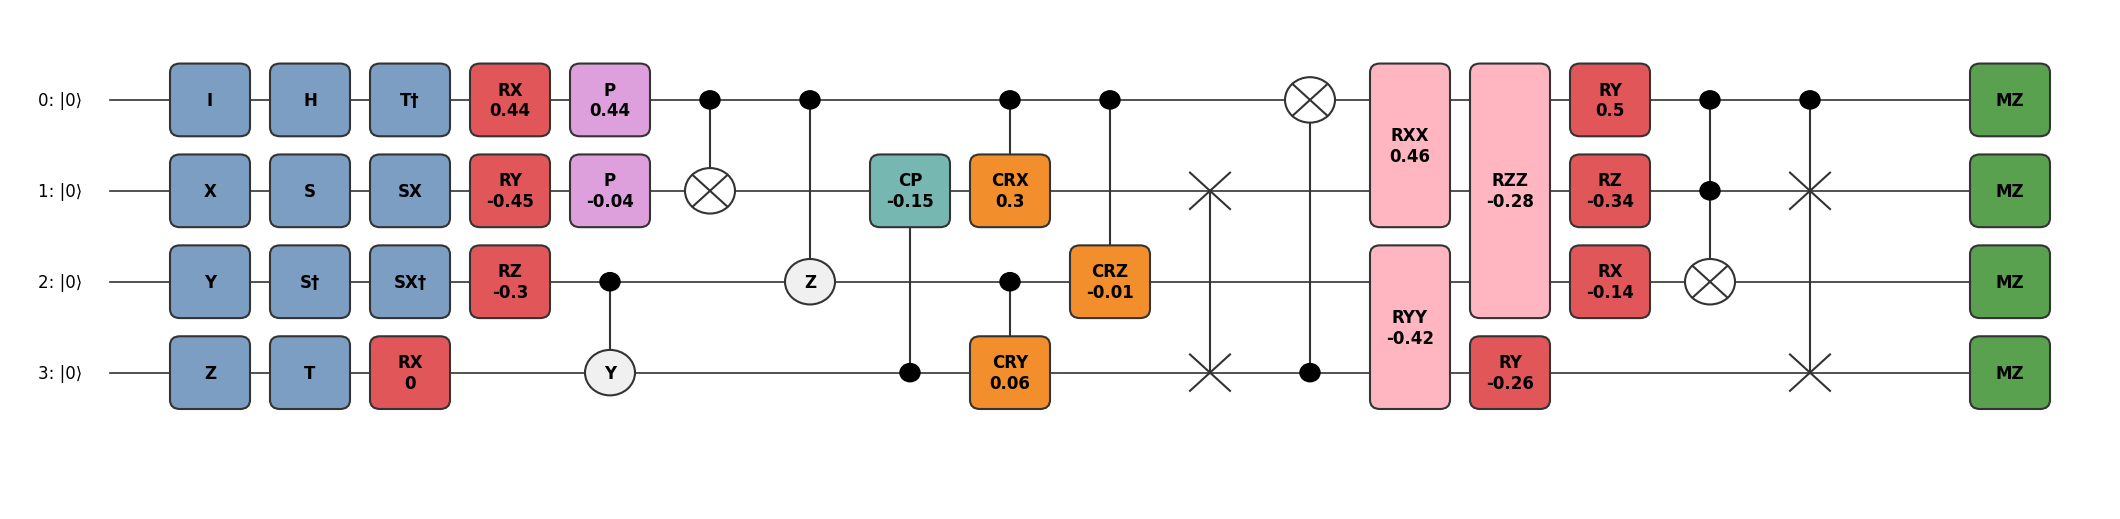

In [10]:
# 文本模式（默认）
print(fq.draw(qdev, format="text", decimals=3, show_all_wires=True, show_initial_state=True))

# Matplotlib 模式
fig, ax = fq.draw(qdev, show_initial_state=True, format="mpl", style="flagquantum")